In [2]:
import numpy as np
import pandas as pd
import itertools
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

# Importing your submodular library functions
from greedy_algorithm.greedy import greedy_submodular_maximization, facility_location_score

# Setting random seed for reproducibility
np.random.seed(42)

### Part 1: Theoretical Approximation Guarantee Verification (Synthetic Data)

In [3]:
def brute_force_optimal(v_size, k, sim_matrix):
    """Finds the absolute global optimum subset using brute force."""
    best_score = -1
    best_subset = None
    for subset in itertools.combinations(range(v_size), k):
        score = facility_location_score(list(subset), sim_matrix)
        if score > best_score:
            best_score = score
            best_subset = subset
    return list(best_subset), best_score

# 1. Generate a small 10x10 synthetic symmetric similarity matrix
V_SIZE_SYNTH = 10
K_BUDGET_SYNTH = 3

random_mat = np.random.rand(V_SIZE_SYNTH, V_SIZE_SYNTH)
synth_sim_matrix = (random_mat + random_mat.T) / 2
np.fill_diagonal(synth_sim_matrix, 1.0)

# 2. Run Brute Force
start = time.time()
bf_subset, bf_score = brute_force_optimal(V_SIZE_SYNTH, K_BUDGET_SYNTH, synth_sim_matrix)
print(f"[Brute Force] Optimal subset: {bf_subset}, Score: {bf_score:.4f} (Time: {time.time()-start:.4f}s)")

# 3. Run Greedy
start = time.time()
greedy_subset = greedy_submodular_maximization(V_SIZE_SYNTH, K_BUDGET_SYNTH, synth_sim_matrix)
greedy_score = facility_location_score(greedy_subset, synth_sim_matrix)
print(f"[Greedy] Selected subset: {greedy_subset}, Score: {greedy_score:.4f} (Time: {time.time()-start:.4f}s)")

# 4. Math Bound Verification
ratio = greedy_score / bf_score
theoretical_bound = 1 - (1 / np.e)

print("\n" + "="*50)
print("SYNTHETIC DATA VERIFICATION RESULT:")
print(f"Empirical Ratio (Greedy / Optimum): {ratio:.4f}")
print(f"Theoretical Bound (1 - 1/e):         {theoretical_bound:.4f}")

[Brute Force] Optimal subset: [0, 3, 9], Score: 8.2694 (Time: 0.0033s)
Starting selection of 3 elements out of 10...
Step 1: Selected element 5, Marginal Gain: 5.7591
Step 2: Selected element 7, Marginal Gain: 1.5779
Step 3: Selected element 1, Marginal Gain: 0.6430
[Greedy] Selected subset: [5, 7, 1], Score: 7.9800 (Time: 0.0000s)

SYNTHETIC DATA VERIFICATION RESULT:
Empirical Ratio (Greedy / Optimum): 0.9650
Theoretical Bound (1 - 1/e):         0.6321


### Part 2: Real-world Evaluation on the Wine Dataset

In [3]:
# 1. Load dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

V_SIZE_WINE = X.shape[1]
K_BUDGET_WINE = 3

# 2. Compute Similarity Matrices (all scaled to [0, 1] interval)
sim_pearson = np.abs(X.corr(method='pearson').values)
sim_spearman = np.abs(X.corr(method='spearman').values)
sim_cosine = cosine_similarity(X.T.values) # similarity between features (transposed)
# Normalize cosine similarity from [-1, 1] to [0, 1] if necessary, but for features it's usually positive
sim_cosine = np.abs(sim_cosine)

matrices = {
    "Pearson Correlation": sim_pearson,
    "Spearman Correlation": sim_spearman,
    "Cosine Similarity": sim_cosine
}

print(f"Loaded Wine dataset with {V_SIZE_WINE} features.")
print(f"Targeting a budget of k = {K_BUDGET_WINE} features.")

Loaded Wine dataset with 13 features.
Targeting a budget of k = 3 features.


In [7]:
results_log = []

print("Evaluating 1 - 1/e bound across different similarity metrics:\n")
for name, mat in matrices.items():
    bf_sub, bf_sc = brute_force_optimal(V_SIZE_WINE, K_BUDGET_WINE, mat)
    gr_sub = greedy_submodular_maximization(V_SIZE_WINE, K_BUDGET_WINE, mat)
    gr_sc = facility_location_score(gr_sub, mat)
    
    em_ratio = gr_sc / bf_sc
    bound_passed = em_ratio >= (1 - (1 / np.e))
    
    results_log.append({
        "Metric": name,
        "Brute Force Subset": bf_sub,
        "Greedy Subset": gr_sub,
        "Ratio": em_ratio,
        "Bound Passed": bound_passed
    })

# Display as DataFrame for clean formatting
df_results = pd.DataFrame(results_log)
df_results

Evaluating 1 - 1/e bound across different similarity metrics:

Starting selection of 3 elements out of 13...
Step 1: Selected element 6, Marginal Gain: 6.3625
Step 2: Selected element 0, Marginal Gain: 1.4582
Step 3: Selected element 2, Marginal Gain: 0.8962
Starting selection of 3 elements out of 13...
Step 1: Selected element 6, Marginal Gain: 6.2791
Step 2: Selected element 0, Marginal Gain: 1.7987
Step 3: Selected element 2, Marginal Gain: 0.7563
Starting selection of 3 elements out of 13...
Step 1: Selected element 0, Marginal Gain: 12.4127
Step 2: Selected element 5, Marginal Gain: 0.1357
Step 3: Selected element 1, Marginal Gain: 0.0966


,Metric,Brute Force Subset,Greedy Subset,Ratio,Bound Passed
0,Pearson Correlation,"[0, 2, 6]","[6, 0, 2]",1.0,True
1,Spearman Correlation,"[0, 2, 6]","[6, 0, 2]",1.0,True
2,Cosine Similarity,"[0, 1, 5]","[0, 5, 1]",1.0,True


<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Anna Kozłowska\AppData\Local\Temp\ipykernel_23936\1044923327.py:27: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("Marginal Gain ($f(S \cup \{v\}) - f(S)$)")


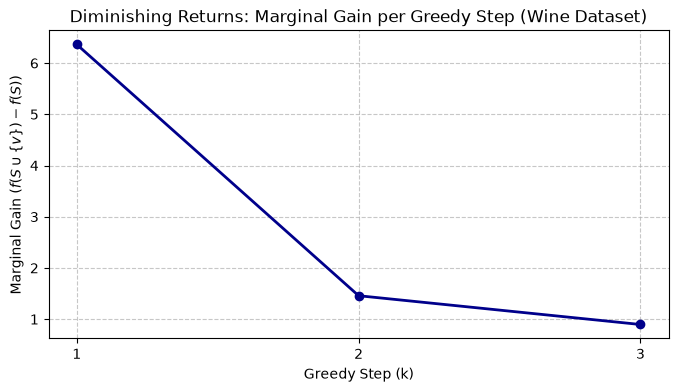

In [6]:
# Let's trace marginal gains for the Pearson Similarity Matrix
chosen_matrix = sim_pearson
S_trace = []
marginal_gains = []

for step in range(K_BUDGET_WINE):
    current_score = facility_location_score(S_trace, chosen_matrix)
    best_gain = -1
    best_element = None
    
    for v in range(V_SIZE_WINE):
        if v in S_trace:
            continue
        gain = facility_location_score(S_trace + [v], chosen_matrix) - current_score
        if gain > best_gain:
            best_gain = gain
            best_element = v
            
    S_trace.append(best_element)
    marginal_gains.append(best_gain)

# Plotting the Marginal Gains
plt.figure(figsize=(8, 4))
plt.plot(range(1, K_BUDGET_WINE + 1), marginal_gains, marker='o', color='darkblue', linewidth=2)
plt.title("Diminishing Returns: Marginal Gain per Greedy Step (Wine Dataset)")
plt.xlabel("Greedy Step (k)")
plt.ylabel("Marginal Gain ($f(S \cup \{v\}) - f(S)$)")
plt.xticks(range(1, K_BUDGET_WINE + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

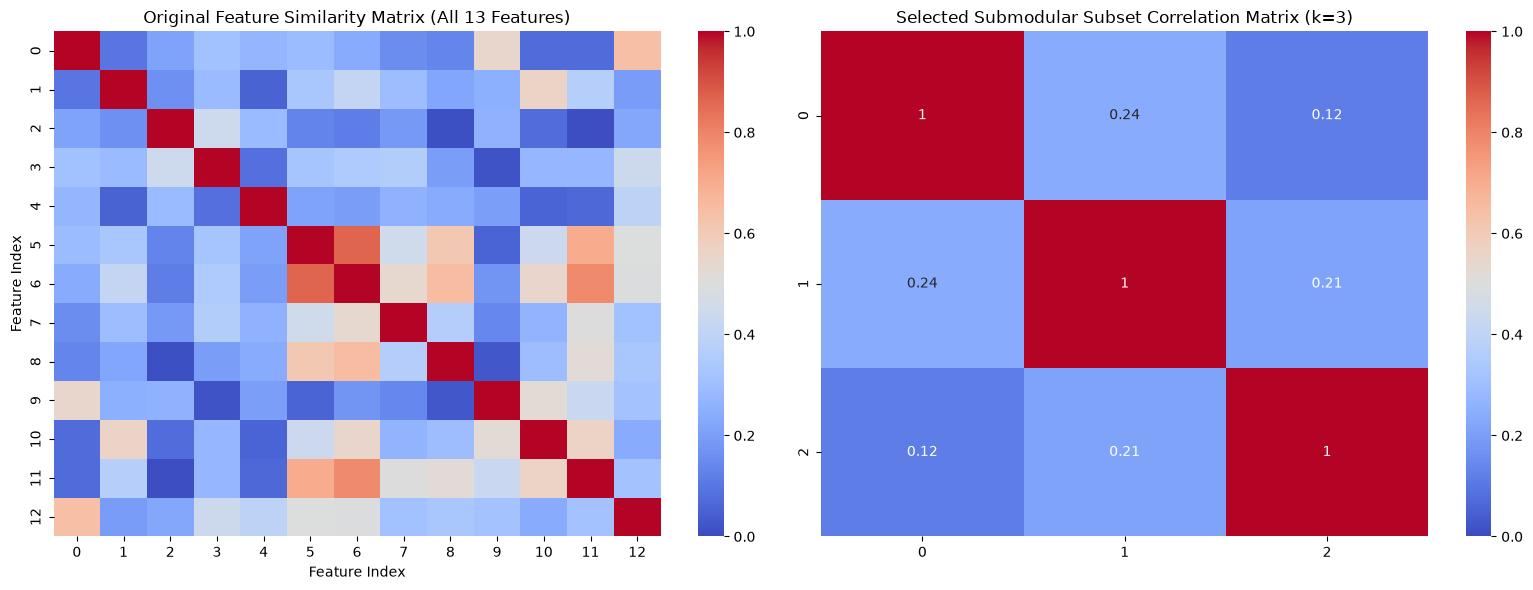

In [8]:
# Extract features selected by greedy using Pearson metric
selected_features_idx = results_log[0]["Greedy Subset"] # Pearson results
selected_features_names = [wine.feature_names[i] for i in selected_features_idx]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Full Dataset Correlation Matrix
sns.heatmap(sim_pearson, annot=False, cmap='coolwarm', vmin=0, vmax=1, ax=ax[0])
ax[0].set_title("Original Feature Similarity Matrix (All 13 Features)")
ax[0].set_xlabel("Feature Index")
ax[0].set_ylabel("Feature Index")

# Heatmap 2: Submodular Selected Features Correlation Matrix
selected_sim = sim_pearson[np.ix_(selected_features_idx, selected_features_idx)]
sns.heatmap(selected_sim, annot=True, cmap='coolwarm', vmin=0, vmax=1,  ax=ax[1])
ax[1].set_title(f"Selected Submodular Subset Correlation Matrix (k={K_BUDGET_WINE})")

plt.tight_layout()
plt.show()

In [5]:
# Split the dataset for classification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Compute baseline feature importance using Random Forest on full training data
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_scaled, y_train)
rf_importances = rf_base.feature_importances_
rf_top_k_indices = np.argsort(rf_importances)[::-1] # Features ordered by importance


Starting selection of 1 elements out of 13...
Step 1: Selected element 6, Marginal Gain: 6.3625
Starting selection of 2 elements out of 13...
Step 1: Selected element 6, Marginal Gain: 6.3625
Step 2: Selected element 0, Marginal Gain: 1.4582
Starting selection of 3 elements out of 13...
Step 1: Selected element 6, Marginal Gain: 6.3625
Step 2: Selected element 0, Marginal Gain: 1.4582
Step 3: Selected element 2, Marginal Gain: 0.8962
Starting selection of 4 elements out of 13...
Step 1: Selected element 6, Marginal Gain: 6.3625
Step 2: Selected element 0, Marginal Gain: 1.4582
Step 3: Selected element 2, Marginal Gain: 0.8962
Step 4: Selected element 4, Marginal Gain: 0.7134
Starting selection of 5 elements out of 13...
Step 1: Selected element 6, Marginal Gain: 6.3625
Step 2: Selected element 0, Marginal Gain: 1.4582
Step 3: Selected element 2, Marginal Gain: 0.8962
Step 4: Selected element 4, Marginal Gain: 0.7134
Step 5: Selected element 1, Marginal Gain: 0.6068
Starting selection o

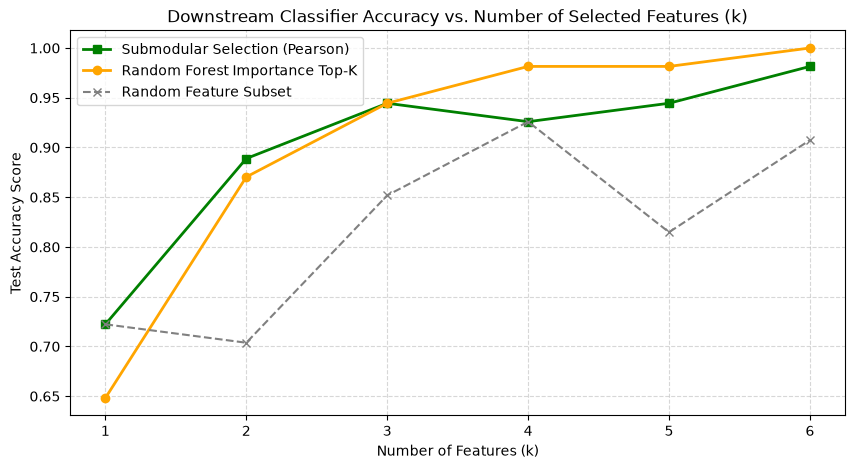

In [ ]:
# Arrays to store accuracies for plotting
k_range = range(1, 7)
submodular_accs = []
rf_importance_accs = []
random_accs = []

for k_val in k_range:
    # A. Submodular selection for current k_val
    sub_idx = greedy_submodular_maximization(V_SIZE_WINE, k_val, sim_pearson)
    clf_sub = RandomForestClassifier(random_state=42)
    clf_sub.fit(X_train_scaled[:, sub_idx], y_train)
    submodular_accs.append(accuracy_score(y_test, clf_sub.predict(X_test_scaled[:, sub_idx])))
    
    # B. Random Forest Top-K Importance selection
    rf_idx = rf_top_k_indices[:k_val]
    clf_rf = RandomForestClassifier(random_state=42)
    clf_rf.fit(X_train_scaled[:, rf_idx], y_train)
    rf_importance_accs.append(accuracy_score(y_test, clf_rf.predict(X_test_scaled[:, rf_idx])))
    
    # C. Random Subset selection
    np.random.seed(42 + k_val)
    rand_idx = np.random.choice(V_SIZE_WINE, k_val, replace=False)
    clf_rand = RandomForestClassifier(random_state=42)
    clf_rand.fit(X_train_scaled[:, rand_idx], y_train)
    random_accs.append(accuracy_score(y_test, clf_rand.predict(X_test_scaled[:, rand_idx])))

# Plotting Classifier Accuracy comparison
plt.figure(figsize=(10, 5))
plt.plot(k_range, submodular_accs, marker='s', label='Submodular Selection (Pearson)', linewidth=2, color='green')
plt.plot(k_range, rf_importance_accs, marker='o', label='Random Forest Importance Top-K', linewidth=2, color='orange')
plt.plot(k_range, random_accs, marker='x', label='Random Feature Subset', linestyle='--', color='gray')

plt.title("Downstream Classifier Accuracy vs. Number of Selected Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Test Accuracy Score")
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In the downstream classification task on the Wine dataset, the supervised Random Forest (RF) importance baseline slightly outperforms our unsupervised submodular feature selection for small values of k. This behavior is theoretically expected: the Wine dataset consists of only 13 distinct features with low structural redundancy, allowing the supervised baseline to directly select features with the highest immediate predictive power with respect to the target variable y. Conversely, our submodular algorithm operates entirely in an unsupervised manner, optimizing for data representation and coverage purely from the feature matrix X. Notably, the submodular selection significantly outperforms the random feature subset baseline, demonstrating that it effectively captures the underlying geometry of the dataset without relying on class labels. The true advantage of the submodular approach—specifically its ability to penalize feature redundancy—is expected to unfold in ultra-high-dimensional spaces, such as the Bioresponse dataset.

In [7]:
# --- 1. DATA PREPARATION (WINE DATASET) ---
data = load_wine()
X = data.data

# Scale features so that geometric similarity is mathematically meaningful
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate a non-negative similarity matrix (shifted cosine to the [0, 1] range)
# Original cosine similarity returns [-1, 1]. We add 1 and divide by 2 to preserve submodularity.
raw_sim = cosine_similarity(X_scaled.T)
sim_matrix = (raw_sim + 1) / 2.0

V_size = X_scaled.shape[1]  # Equals 13 for the Wine dataset

# --- 2. IMPORT YOUR SUBMODULAR FUNCTIONS ---
# If these functions are defined in the same notebook, you can comment out this import.
from greedy_algorithm.greedy import greedy_submodular_maximization, facility_location_score

# --- 3. COMPARATIVE LOOP (FROM 1 TO 13 FEATURES) ---
results_greedy = []
results_optimal = []
ratios = []
k_values = list(range(1, V_size + 1))

Starting comparative execution (Greedy vs Brute-Force Optimum)...
Starting selection of 1 elements out of 13...
Step 1: Selected element 5, Marginal Gain: 8.2899
k= 1 | Greedy Score:   8.29 | Optimal Score:   8.29 | Ratio: 1.0000
Starting selection of 2 elements out of 13...
Step 1: Selected element 5, Marginal Gain: 8.2899
Step 2: Selected element 2, Marginal Gain: 1.5785
k= 2 | Greedy Score:   9.87 | Optimal Score:   9.96 | Ratio: 0.9909
Starting selection of 3 elements out of 13...
Step 1: Selected element 5, Marginal Gain: 8.2899
Step 2: Selected element 2, Marginal Gain: 1.5785
Step 3: Selected element 0, Marginal Gain: 0.5720
k= 3 | Greedy Score:  10.44 | Optimal Score:  10.70 | Ratio: 0.9756
Starting selection of 4 elements out of 13...
Step 1: Selected element 5, Marginal Gain: 8.2899
Step 2: Selected element 2, Marginal Gain: 1.5785
Step 3: Selected element 0, Marginal Gain: 0.5720
Step 4: Selected element 1, Marginal Gain: 0.4714
k= 4 | Greedy Score:  10.91 | Optimal Score:  

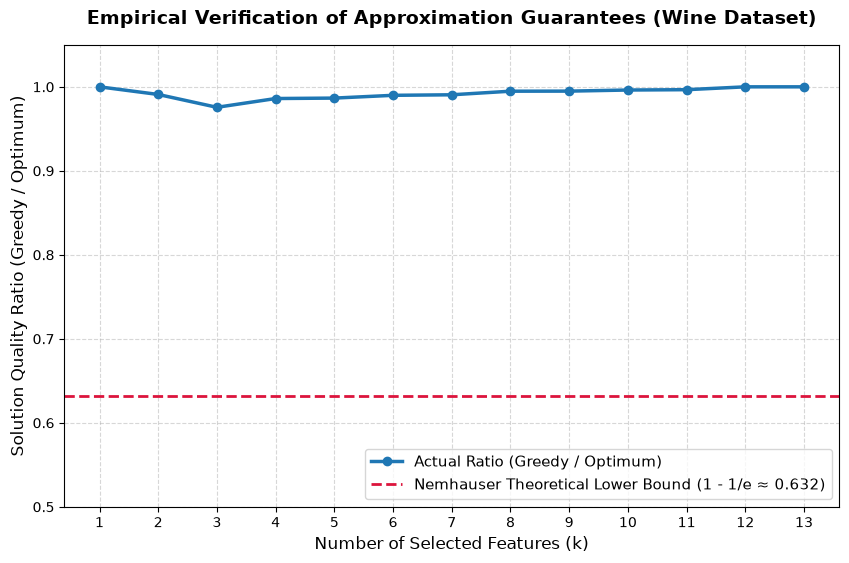

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity


print("Starting comparative execution (Greedy vs Brute-Force Optimum)...")
for k in k_values:
    # A. Greedy Solution
    greedy_subset = greedy_submodular_maximization(V_size, k, sim_matrix)
    greedy_score = facility_location_score(greedy_subset, sim_matrix)
    results_greedy.append(greedy_score)
    
    # B. Optimal Solution (Brute-force)
    # Generate absolutely all possible k-element combinations from the 13 available features
    all_combinations = list(itertools.combinations(range(V_size), k))
    
    best_optimal_score = -1
    for comb in all_combinations:
        score = facility_location_score(list(comb), sim_matrix)
        if score > best_optimal_score:
            best_optimal_score = score
            
    results_optimal.append(best_optimal_score)
    
    # C. Calculate the Ratio
    ratio = greedy_score / best_optimal_score
    ratios.append(ratio)
    
    print(f"k={k:2d} | Greedy Score: {greedy_score:6.2f} | Optimal Score: {best_optimal_score:6.2f} | Ratio: {ratio:.4f}")

# --- 4. PLOTTING THE RESULTS ---
plt.figure(figsize=(10, 6))

# Plot the actual empirical ratios from your experiment
plt.plot(k_values, ratios, marker='o', color='#1f77b4', linewidth=2.5, label='Actual Ratio (Greedy / Optimum)')

# Draw the theoretical worst-case lower bound line (1 - 1/e)
theoretical_bound = 1 - (1 / np.e)
plt.axhline(y=theoretical_bound, color='crimson', linestyle='--', linewidth=2, 
            label=f'Nemhauser Theoretical Lower Bound (1 - 1/e ≈ {theoretical_bound:.3f})')

# Chart styling and labeling
plt.title("Empirical Verification of Approximation Guarantees (Wine Dataset)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Selected Features (k)", fontsize=12)
plt.ylabel("Solution Quality Ratio (Greedy / Optimum)", fontsize=12)
plt.xticks(k_values)
plt.ylim(0.5, 1.05)  # Set Y bounds to perfectly display the 0.632 threshold and 1.0 maximum
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)

# Display the final plot
plt.show()

In [3]:
X

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

Rozpoczynam wybór reprezentatywnych WIERSZY z uniwersum V = 178...
Starting selection of 1 elements out of 178...
Step 1: Selected element 81, Marginal Gain: 92.1437
k= 1 | Zachłanne wiersze:  92.14 | Optymalne wiersze:  92.14 | Stosunek: 1.0000
Starting selection of 2 elements out of 178...
Step 1: Selected element 81, Marginal Gain: 92.1437
Step 2: Selected element 147, Marginal Gain: 33.8701
k= 2 | Zachłanne wiersze: 126.01 | Optymalne wiersze: 132.10 | Stosunek: 0.9539
Starting selection of 3 elements out of 178...
Step 1: Selected element 81, Marginal Gain: 92.1437
Step 2: Selected element 147, Marginal Gain: 33.8701
Step 3: Selected element 5, Marginal Gain: 16.0021
k= 3 | Zachłanne wiersze: 142.02 | Optymalne wiersze: 144.71 | Stosunek: 0.9814


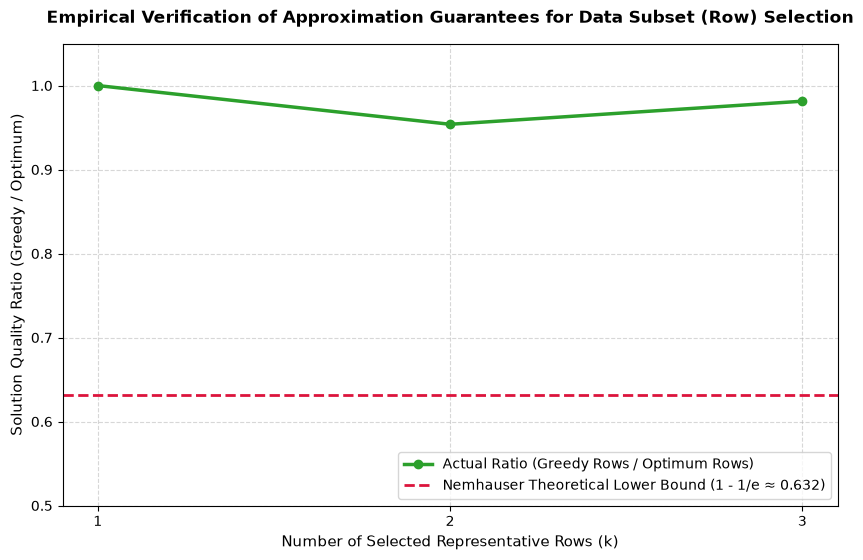

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. PRZYGOTOWANIE DANYCH (ZBIÓR WINE - WIERSZE) ---
data = load_wine()
X = data.data

# Standaryzacja obiektów (wierszy), aby odległości i kąty miały sens geometryczny
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Obliczenie nieujemnej macierzy podobieństwa MIĘDZY WIERSZAMI (N x N)
# Używamy przesuniętego kosinusa do przedziału [0, 1]
# Zauważ, że przekazujemy X_scaled bezpośrednio (a nie X_scaled.T jak dla cech)
raw_sim = cosine_similarity(X_scaled)
sim_matrix = (raw_sim + 1) / 2.0

V_size = X_scaled.shape[0]  # Wynosi 178 (liczba wierszy w zbiorze Wine)

# --- 2. IMPORT WASZYCH FUNKCJI ---
# Upewnij się, że ścieżka do Twojego pliku greedy jest poprawna.
# Funkcje działają identycznie, ponieważ dla algorytmu indeksy to po prostu "elementy uniwersum"
from greedy_algorithm.greedy import greedy_submodular_maximization, facility_location_score

# --- 3. PĘTLA PORÓWNAWCZA (WYBÓR OD 1 DO 4 WIERSZY) ---
# Ograniczamy k do 4, ponieważ kombinacji kombinatorycznych z 178 wierszy dla k=5 
# jest aż 1,2 miliarda, co zawiesiłoby komputer przy pełnym brute-force.
k_values = [1, 2, 3]
results_greedy = []
results_optimal = []
ratios = []

print(f"Rozpoczynam wybór reprezentatywnych WIERSZY z uniwersum V = {V_size}...")

for k in k_values:
    # A. Rozwiązanie zachłanne (Wybór wierszy)
    greedy_subset = greedy_submodular_maximization(V_size, k, sim_matrix)
    greedy_score = facility_location_score(greedy_subset, sim_matrix)
    results_greedy.append(greedy_score)
    
    # B. Rozwiązanie optymalne (Brute-force po wierszach)
    all_combinations = list(itertools.combinations(range(V_size), k))
    
    best_optimal_score = -1
    for comb in all_combinations:
        score = facility_location_score(list(comb), sim_matrix)
        if score > best_optimal_score:
            best_optimal_score = score
            
    results_optimal.append(best_optimal_score)
    
    # C. Obliczenie stosunku (Ratio)
    ratio = greedy_score / best_optimal_score
    ratios.append(ratio)
    
    print(f"k={k:2d} | Zachłanne wiersze: {greedy_score:6.2f} | Optymalne wiersze: {best_optimal_score:6.2f} | Stosunek: {ratio:.4f}")

# --- 4. GENEROWANIE WYKRESU DLA WIERSZY ---
plt.figure(figsize=(10, 6))

# Wykres linii rzeczywistego stosunku z eksperymentu na wierszach
plt.plot(k_values, ratios, marker='o', color='#2ca02c', linewidth=2.5, label='Actual Ratio (Greedy Rows / Optimum Rows)')

# Przerywana linia teoretycznej dolnej granicy (1 - 1/e)
theoretical_bound = 1 - (1 / np.e)
plt.axhline(y=theoretical_bound, color='crimson', linestyle='--', linewidth=2, 
            label=f'Nemhauser Theoretical Lower Bound (1 - 1/e ≈ {theoretical_bound:.3f})')

# Personalizacja i styl wykresu
plt.title("Empirical Verification of Approximation Guarantees for Data Subset (Row) Selection", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Number of Selected Representative Rows (k)", fontsize=11)
plt.ylabel("Solution Quality Ratio (Greedy / Optimum)", fontsize=11)
plt.xticks(k_values)
plt.ylim(0.5, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=10)

# Pokazanie wykresu
plt.show()

### tu ulepszony wykres, z dodanym rf i feature_importance (wsm najlepszy, bo nadzorowany)

Evaluating classification accuracy for different feature selection methods...
Starting selection of 1 elements out of 13...
Step 1: Selected element 5, Marginal Gain: 8.2899
k=1 | Greedy Acc: 0.6122 | Optimal Acc: 0.6122 | Random Acc: 0.5712
Starting selection of 2 elements out of 13...
Step 1: Selected element 5, Marginal Gain: 8.2899
Step 2: Selected element 2, Marginal Gain: 1.5785
k=2 | Greedy Acc: 0.6006 | Optimal Acc: 0.7810 | Random Acc: 0.7170
Starting selection of 3 elements out of 13...
Step 1: Selected element 5, Marginal Gain: 8.2899
Step 2: Selected element 2, Marginal Gain: 1.5785
Step 3: Selected element 0, Marginal Gain: 0.5720
k=3 | Greedy Acc: 0.8546 | Optimal Acc: 0.9163 | Random Acc: 0.8007
Starting selection of 4 elements out of 13...
Step 1: Selected element 5, Marginal Gain: 8.2899
Step 2: Selected element 2, Marginal Gain: 1.5785
Step 3: Selected element 0, Marginal Gain: 0.5720
Step 4: Selected element 1, Marginal Gain: 0.4714
k=4 | Greedy Acc: 0.8432 | Optimal

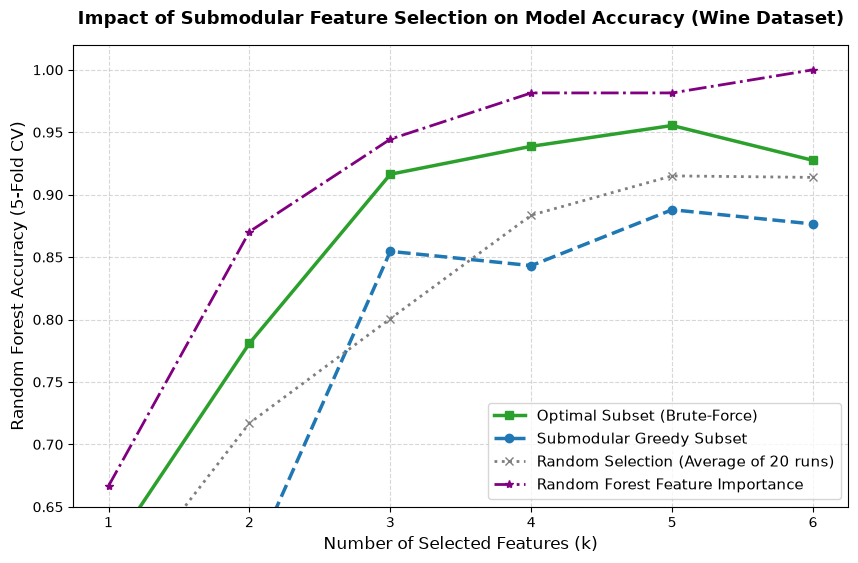

In [13]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# --- 1. DATA PREPARATION ---
data = load_wine()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute non-negative similarity matrix for the submodular function
raw_sim = cosine_similarity(X_scaled.T)
sim_matrix = (raw_sim + 1) / 2.0

V_size = X_scaled.shape[1]  # 13 features

# --- 2. IMPORT YOUR SUBMODULAR FUNCTIONS ---
from greedy_algorithm.greedy import greedy_submodular_maximization, facility_location_score

# --- 3. BENCHMARKING ACCURACY IN A LOOP ---
# We limit k from 1 to 6 because brute-forcing all combinations for k > 6 
# takes longer and the model accuracy already reaches 100% early on.
k_values = list(range(1, 7))  

accuracy_greedy = []
accuracy_optimal = []
accuracy_random = []

rf = RandomForestClassifier(n_estimators=50, random_state=42)

print("Evaluating classification accuracy for different feature selection methods...")

for k in k_values:
    # --- A. Submodular Greedy Accuracy ---
    greedy_subset = greedy_submodular_maximization(V_size, k, sim_matrix)
    X_greedy = X_scaled[:, greedy_subset]
    acc_greedy = np.mean(cross_val_score(rf, X_greedy, y, cv=5, scoring='accuracy'))
    accuracy_greedy.append(acc_greedy)
    
    # --- B. Optimal Submodular Accuracy (Brute-Force) ---
    all_combinations = list(itertools.combinations(range(V_size), k))
    best_optimal_score = -1
    best_optimal_subset = None
    
    # Find the mathematically optimal subset based on Facility Location
    for comb in all_combinations:
        score = facility_location_score(list(comb), sim_matrix)
        if score > best_optimal_score:
            best_optimal_score = score
            best_optimal_subset = comb
            
    X_optimal = X_scaled[:, list(best_optimal_subset)]
    acc_optimal = np.mean(cross_val_score(rf, X_optimal, y, cv=5, scoring='accuracy'))
    accuracy_optimal.append(acc_optimal)
    
    # --- C. Random Selection Baseline Accuracy ---
    # We average over 20 random trials to get a stable baseline
    random_trials = []
    for _ in range(20):
        random_subset = np.random.choice(range(V_size), size=k, replace=False)
        X_random = X_scaled[:, random_subset]
        acc_rand = np.mean(cross_val_score(rf, X_random, y, cv=5, scoring='accuracy'))
        random_trials.append(acc_rand)
    accuracy_random.append(np.mean(random_trials))
    
    print(f"k={k} | Greedy Acc: {acc_greedy:.4f} | Optimal Acc: {acc_optimal:.4f} | Random Acc: {np.mean(random_trials):.4f}")


rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)
indices_rf_importance = np.argsort(rf_selector.feature_importances_)[::-1]

X_train_np = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else np.array(X_train)
X_test_np = X_test.to_numpy() if hasattr(X_test, 'to_numpy') else np.array(X_test)

k_values_rf = list(range(1, max(k_values) + 1)) 
rf_importance_accuracies = []

for k in k_values_rf:
    selected_features = indices_rf_importance[:k]
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_np[:, selected_features], y_train)
    y_pred = clf.predict(X_test_np[:, selected_features])
    rf_importance_accuracies.append(accuracy_score(y_test, y_pred))

# --- 4. PLOTTING THE ACCURACY COMPARISON ---
plt.figure(figsize=(10, 6))

# Plot the three lines
plt.plot(k_values, accuracy_optimal, marker='s', color='#2ca02c', linewidth=2.5, label='Optimal Subset (Brute-Force)')
plt.plot(k_values, accuracy_greedy, marker='o', color='#1f77b4', linewidth=2.5, linestyle='--', label='Submodular Greedy Subset')
plt.plot(k_values, accuracy_random, marker='x', color='#7f7f7f', linewidth=2.0, linestyle=':', label='Random Selection (Average of 20 runs)')
plt.plot(k_values_rf, rf_importance_accuracies, marker='*', color='purple', linestyle='-.', linewidth=2, label='Random Forest Feature Importance')

# Chart layout styling
plt.title("Impact of Submodular Feature Selection on Model Accuracy (Wine Dataset)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Number of Selected Features (k)", fontsize=12)
plt.ylabel("Random Forest Accuracy (5-Fold CV)", fontsize=12)
plt.xticks(k_values)
plt.ylim(0.65, 1.02)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)

# Display the chart
plt.show()